# Storylines simulations

Content of this notebook:
1. Finding and requesting storyline data
2. Plotting regional HEALPix data
3. Interpolating HEALPix data to a lon-lat grid
4. Plotting HEALPix without interpolation

**Further material:**   
- In the [Climate DT user guide](https://platform.destine.eu/services/documents-and-api/doc/?service_name=climate-dt-user-guide) navigate to "Simulations" -> "Storyline Simulations".
- Publication by John et al. 2026 [Global Kilometer-Scale Cliamte STorylines Using Spectral Nudging](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2025MS005326)
- [ECMWF parameter database](https://codes.ecmwf.int/grib/param-db/)


In [57]:
import earthkit.data as ekd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

### 1. Finding and requesting the storylines data <a name="findingdata"></a>

**Task:**
We want to request the following data: The storylines simulation ensemble member 1 for the present climate for July 2025 (e.g. 12 UTC). We are insterested in the 2m temperature (param: 167). Create a matching request for this data using the user guide experiment ID as helper.

**Reminder:**
The request keys can be found in [the data keys overview](../04_Cheatsheets/data_keys.rst).

In [2]:
request = {
     'activity': 'story-nudging',
     'class': 'd1',
     'dataset': 'climate-dt',
     'experiment': 'hist',
     'expver': '0001',
     'model': 'ifs-fesom',
     'generation': '2',
     'realization': '1',
     'resolution': 'high',
     'date': '20250701/to/20250731',
     'time': '1200',
     'stream': 'clte',
     'type': 'fc',
     'levtype': 'sfc',
     'param': '167',
}

**Task** Reduce the region so that it covers only Finland using the [Bounding Box feature](https://polytope.readthedocs.io/en/latest/Service/Features/boundingbox/) that was introduced in section 2. E.g. latitude: 59 to 71 degree and longitude: 19 to 32 degree.

In [3]:
request_finland = request | {
    "feature": {
        "type": "boundingbox",
        "points" : [[59, 19], [71, 32]],
    },
}

**Task:** Find out on which data-bridge the data is located and request the data.

In [4]:
data =  ekd.from_source("polytope", "destination-earth", request_finland, stream=False, \
                               address='polytope.mn5.apps.dte.destination-earth.eu')

2026-06-08 16:44:51 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-08 16:44:51 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20250701/to/20250731\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 59\n'
            '    - 19\n'
            '  - - 71\n'
            '    - 32\n'
            '  type: boundingbox\n'
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '167'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-08 16:44:51 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-08 16:44:52 - INFO - Request accepted. Please poll ./01e41dc1-649d-466c-af3d-0c769059ecc6 for

Note: `data.ls()` does not work when using the bounding box feature. The data will be downloaded as a Covjson format so some capabilities of earthkit do not work currently. `data.ls()` works for the GRIBReader format.

**Task:** Convert the data to xarray.

In [5]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 1MB
Dimensions:    (datetimes: 31, number: 1, steps: 1, points: 5050)
Coordinates:
  * datetimes  (datetimes) <U20 2kB '2025-07-01T12:00:00Z' ... '2025-07-31T12...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 40kB 0 1 2 3 4 5 ... 5044 5045 5046 5047 5048 5049
    latitude   (points) float64 40kB 59.01 59.01 59.01 59.01 ... 71.0 71.0 71.0
    longitude  (points) float64 40kB 21.09 20.55 20.82 ... 24.13 27.61 20.65
    levelist   (points) float64 40kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 1MB 284.6 ... 284.6
Attributes: (12/16)
    activity:       story-nudging
    class:          d1
    dataset:        climate-dt
    Forecast date:  2025-07-01T12:00:00Z
    experiment:     hist
    expver:         0001
    ...             ...
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    step:           0
    date:           2025-07-01T12:00:00Z

### 2. Plotting regional HEALPix data

There are different options to plot the healpix data for regional areas. Here we show two possible options with cartopy and one for earthkit-plots. You can choose which tool to use based on your use-case.

**Earthkit plots:**
With earthkit plots ([Docs](https://earthkit-plots.readthedocs.io/en/stable/index.html)) you can plot xarray data. In the docs you can find many different examples. Earthkit plots acts as a more high-level plotting tool.

/home/kiszlert/miniforge3/envs/climatedt_workshop/lib/python3.14/site-packages/earthkit/plots/styles/__init__.py:623: UserWarning: The following kwargs were not used by contour: 'transform_first'
  return ax.tricontourf(x, y, values, *args, **kwargs)
/home/kiszlert/miniforge3/envs/climatedt_workshop/lib/python3.14/site-packages/earthkit/plots/quickplot.py:152: UserWarning: Failed to execute title on given data with: 
unsupported format string passed to NoneType.__format__

consider constructing the plot manually.
  warnings.warn(


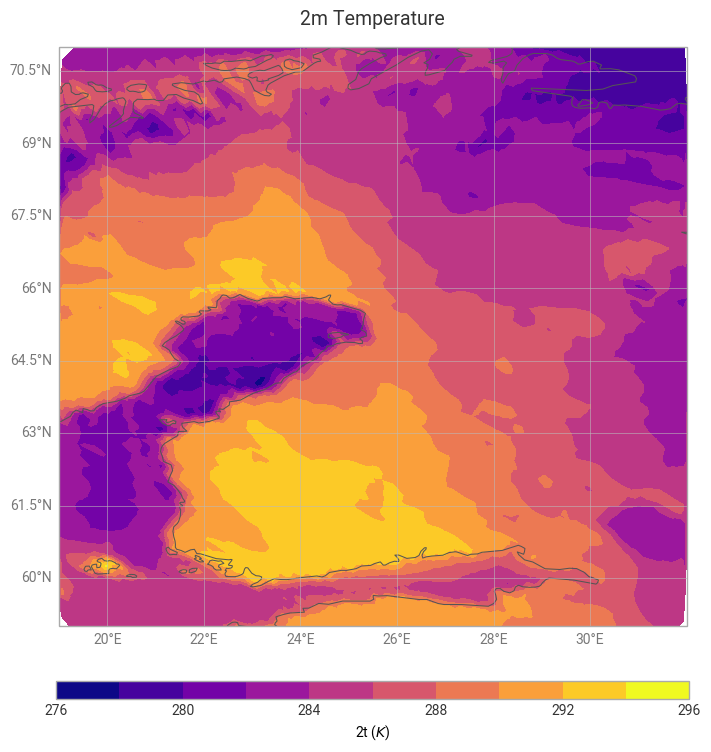

In [6]:
import earthkit.plots as ekp

da = ds.isel(datetimes=0, number=0, steps=0)  # pick one time step

chart = ekp.quickplot(da)
chart.title("2m Temperature")
chart.show()


This looks a bit awkward. How can we fix the projection? We can add a domain to the map!

**Task:** Add `domain="Finland"` as option in the `quickplot()` function.

/home/kiszlert/miniforge3/envs/climatedt_workshop/lib/python3.14/site-packages/earthkit/plots/styles/__init__.py:623: UserWarning: The following kwargs were not used by contour: 'transform_first'
  return ax.tricontourf(x, y, values, *args, **kwargs)
/home/kiszlert/miniforge3/envs/climatedt_workshop/lib/python3.14/site-packages/earthkit/plots/quickplot.py:152: UserWarning: Failed to execute title on given data with: 
unsupported format string passed to NoneType.__format__

consider constructing the plot manually.
  warnings.warn(


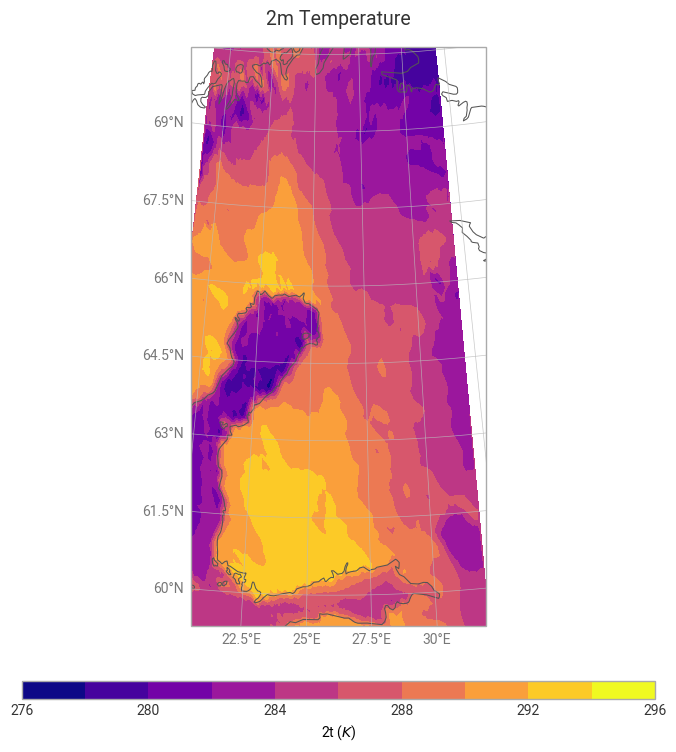

In [7]:
chart= ekp.quickplot(da, domain="Finland")
chart.title("2m Temperature")
chart.show()

As next step we will continue with examples for how to plot with [cartopy](https://cartopy.readthedocs.io/stable/) which is a widely used python package for geospatial data processing. 

**Scatter plot:** For this we use the xarray data and have to select specific dimensions. Then we directly plot the data point by point. This is not the pretiest way, but gives exactly the data at the point which it is assigned to.

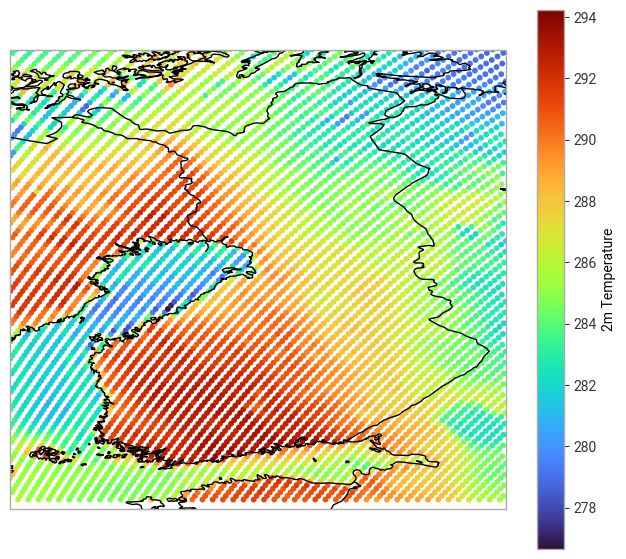

In [8]:
da = ds.isel(datetimes=0, number=0, steps=0)  # pick one time step

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([19, 32, 59, 71])  # Finland bounds

sc = ax.scatter(da.longitude, da.latitude, c=da.values(),
                  transform=ccrs.PlateCarree(), s=10, cmap='turbo')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
plt.colorbar(sc, ax=ax, label='2m Temperature')
#plt.title(str(da.datetimes.values))
plt.show()


**Simple interpolated pcolormesh:** In this example you see how you can use scipy to regrid the data to a specified combination of points. For this too we use the cartopy data.

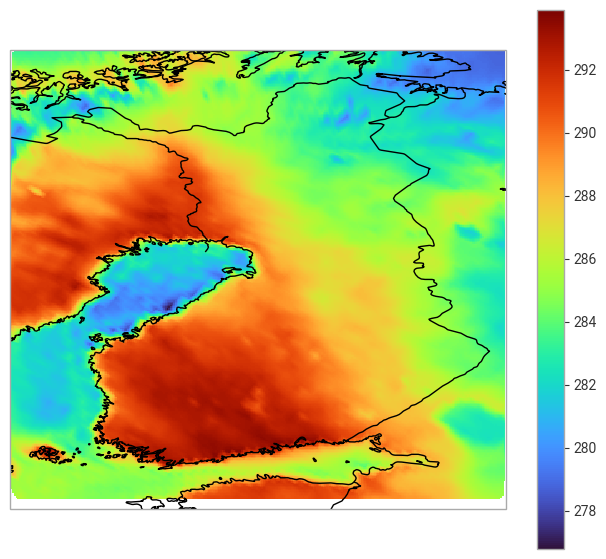

In [9]:
from scipy.interpolate import griddata

da = ds.isel(datetimes=0, number=0, steps=0)  # pick one time step

lons, lats, vals = da.longitude.values, da.latitude.values, da['2t'].values

lat_g = np.linspace(59, 71, 300)
lon_g = np.linspace(19, 32, 300)
lo, la = np.meshgrid(lon_g, lat_g)
vals_grid = griddata((lons, lats), vals, (lo, la), method='linear')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([19, 32, 59, 71])
pcm = ax.pcolormesh(lon_g, lat_g, vals_grid, transform=ccrs.PlateCarree(), cmap='turbo')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
plt.colorbar(pcm, ax=ax)
plt.show()

Now we have a figure but we don't know what lon-lat resolution this actually is. This brings us to our next topic.

## 3. Interpolating HEALPix to lon-lat grids

There are different options to regrid the data. Here two options are demonstrated (there are more). 

### 3.1. Earthkit regrid
We use the regridding functionality in earthkit-regrid. For this we need to stream the global data and then regrid it to a lonlat resolution of our choice.

In [10]:
import earthkit.regrid as ekr

# Use global data (the request without bounding box) for interpolation.
data_full = ekd.from_source("polytope", "destination-earth", request, stream=False, \
                               address='polytope.mn5.apps.dte.destination-earth.eu')

# remapping to 0.2 degree lonlat grid
data_latlon = ekr.interpolate(data_full, out_grid={"grid": [0.2,0.2]}, method="linear")

2026-06-08 16:45:19 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-08 16:45:19 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20250701/to/20250731\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '167'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-08 16:45:19 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-08 16:45:20 - INFO - Request accepted. Please poll ./52643b39-adf6-4f96-9032-7c9ea98778df for status
2026-06-08 16:45:20 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-08 16:45:20 - INFO - Checking request status (52643b39-adf6-4f96-9032-7c9ea98778df)

### 3.2. Server side regridding

Another option is to regrid the data on the server side. A more in depth example can be found in the [Polytope examples](https://github.com/destination-earth-digital-twins/polytope-examples/blob/main/climate-dt/full-field-post-processing/climate-dt-earthkit-serverside-interpolation.ipynb). To do this you can extend the request that you already have created by adding the following keys: 

```python
'grid': 'val1/val2', # degree for interpolation
'interpolation':'grid-box-average', # this is for conservative interpolation
```
In the docs you can find more information about possible interpolation choices.

In [11]:
request_regrid = request | {
    'grid': '0.2/0.2',
    'interpolation':'grid-box-average', # this is for conservative interpolation
}

**Attention:** The bounding box feature does not work with the server side interpolation. Instead you must use the key `'area':'north/west/south/east'`. 

**Task:** Use the server side interpolation to get the same area as with the bounding box. Check the data output with `data_regrid.ls()`. 

In [12]:
request_regrid = request | {
    'grid': '0.2/0.2',
    'interpolation':'grid-box-average',
    'area': '71/19/57/32'
}

In [ ]:
data_regrid = ekd.from_source("polytope", "destination-earth", request_regrid, stream=False, \
                               address='polytope.mn5.apps.dte.destination-earth.eu')

In [15]:
data_regrid.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,2t,heightAboveGround,2,20250701,1200,0,fc,None,regular_ll
1,ecmf,2t,heightAboveGround,2,20250702,1200,0,fc,None,regular_ll
2,ecmf,2t,heightAboveGround,2,20250703,1200,0,fc,None,regular_ll
3,ecmf,2t,heightAboveGround,2,20250704,1200,0,fc,None,regular_ll
4,ecmf,2t,heightAboveGround,2,20250705,1200,0,fc,None,regular_ll
5,ecmf,2t,heightAboveGround,2,20250706,1200,0,fc,None,regular_ll
6,ecmf,2t,heightAboveGround,2,20250707,1200,0,fc,None,regular_ll
7,ecmf,2t,heightAboveGround,2,20250708,1200,0,fc,None,regular_ll
8,ecmf,2t,heightAboveGround,2,20250709,1200,0,fc,None,regular_ll
9,ecmf,2t,heightAboveGround,2,20250710,1200,0,fc,None,regular_ll


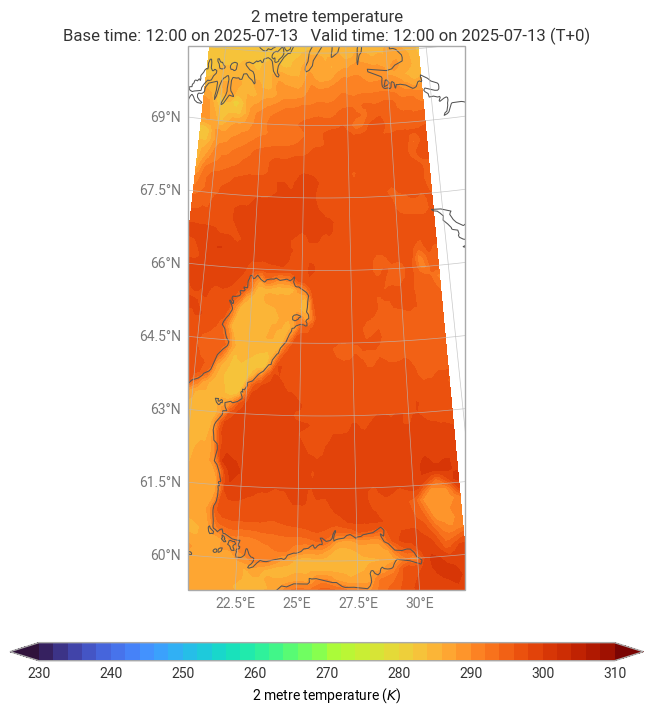

In [16]:
# Using earthkit quickplot to check if the data was created as planned.
ekp.quickplot(data_regrid.sel(dataDate=20250713), domain="Finland").show()

## 4. HEALPix plotting without interpolation

New in this section:
- Getting a country shape as polygon
- Downloading a polygon


This example is adapted from the [Polytope examples](https://github.com/destination-earth-digital-twins/polytope-examples/blob/main/climate-dt/explorer/04_lazy_browse_portfolio_hourly.ipynb).

In this demonstrator a polygon is used to define the area of a country that should be extracted from Polytope. This works the same as using the "bounding box" feature that was introduced before. Instead of the bounding box we can use the [Polygon feature](https://polytope.readthedocs.io/en/latest/Service/Features/polygon/).

Where do you get the country polygon from? From [earthkit-geo](https://earthkit-geo.readthedocs.io/en/stable/).

In [ ]:
import earthkit.geo.cartography

# Get country boundary from Natural Earth via earthkit-geo
countries = ["Finland"]
shapes = earthkit.geo.cartography.country_polygons(countries, resolution=50e6)

Make a request including the feature of type "polygon".

In [27]:
request_polygon = request | {
        "feature": {
        #"axes": ["longitude", "latitude"],
        "type": "polygon",
        "shape": shapes
    },
}

Request the data

In [28]:
data_polygon =  ekd.from_source("polytope", "destination-earth", request_polygon, stream=False, \
                               address='polytope.mn5.apps.dte.destination-earth.eu')

2026-06-08 16:46:40 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-08 16:46:40 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20250701/to/20250731\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  shape:\n'
            '  - - - 60.148339843749994\n'
            '      - 21.506738281250023\n'
            '    - - 60.172314453125\n'
            '      - 21.567968750000006\n'
            '    - - 60.168994140625\n'
            '      - 21.634082031250017\n'
            '    - - 60.140869140625\n'
            '      - 21.64814453125001\n'
            '    - - 60.107812499999994\n'
            '      - 21.628320312500023\n'
            '    - - 60.097900390625\n'
            '      - 21.540625000000006\n'
            '    - - 60.126806640625\n'
            '      - 21.48603515625001\n'
            '    - - 60.14833984374

Convert to xarray

In [29]:
ds_polygon = data_polygon.to_xarray()
ds_polygon

<xarray.Dataset> Size: 573kB
Dimensions:    (datetimes: 31, number: 1, steps: 1, points: 2036)
Coordinates:
  * datetimes  (datetimes) <U20 2kB '2025-07-01 12:00:00Z' ... '2025-07-31 12...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 16kB 0 1 2 3 4 5 ... 2030 2031 2032 2033 2034 2035
    latitude   (points) float64 16kB 59.87 59.96 60.06 ... 69.89 69.98 69.98
    longitude  (points) float64 16kB 23.05 23.4 22.64 ... 28.15 27.45 27.87
    levelist   (points) float64 16kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 505kB 290.9 ... 296.0
Attributes: (12/15)
    activity:     story-nudging
    class:        d1
    dataset:      climate-dt
    experiment:   hist
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2025-07-01 12:00:00Z

Now we create a quick plot and see if everything worked as planned:

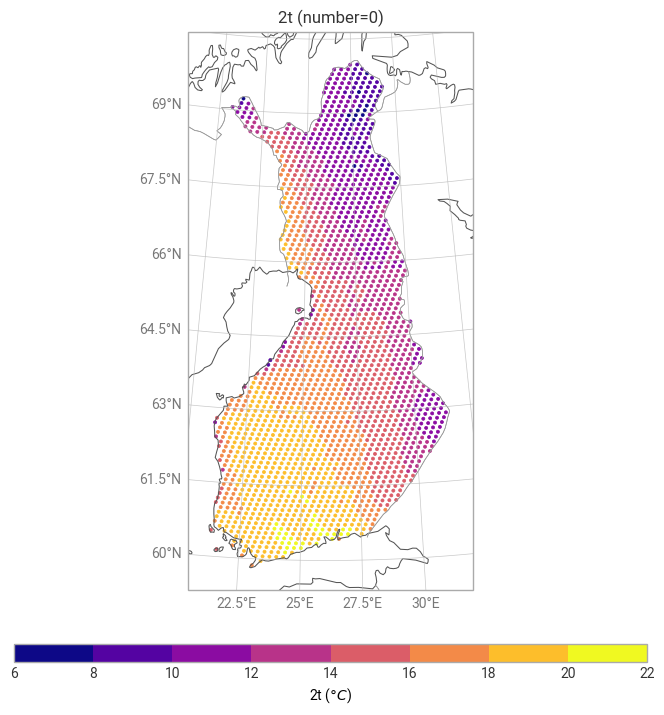

In [30]:
chart = earthkit.plots.Map(domain=countries)
chart.point_cloud(
    ds_polygon.isel(datetimes=0)['2t'],
    units="celsius"
)

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("{variable_name} (number={number})")

chart.legend()

chart.show()

Now we want to plot the data similarly to the pcolormesh plot but using the actual HEALPix data. For this multiple steps are required:

In [56]:
# Import the required modules
from matplotlib.collections import PolyCollection
import healpy as hp

In [35]:
# First we get the variable and make it "flat"
da = ds_polygon["2t"].squeeze()
values = da.values.ravel()

# Get coordinates as values
lats = ds_polygon.coords["latitude"].values
lons = ds_polygon.coords["longitude"].values

**Nside resolution**   

Note from Gorski et al.,2024 (https://healpix.sourceforge.io/pdf/intro.pdf):
"The resolution of the grid is expressed by the parameter **Nside** which defines the number of divisions along the side of a base-resolution pixel that is needed to reach a desired high-resolution partition."

In Climate DT the resolution is encoded as "high" and "standard". Therefore, you need to check the user guide under "Data catalogue" what resolution is what or check in the cheat sheets [data_keys.md](../04_Cheatsheets/data_keys.md). Here we are working with a 10km simulation and are accessing the "high" resolution so the nside is 512.

In [ ]:
# HEALPix pixel indices (NESTED) as you need the "Angular coordinates of a point on the sphere".
theta = np.radians(90.0 - lats)
phi = np.radians(lons)

# The nside from the healpix data
nside = 512

# get pixel ids
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

# "Returns an array containing vectors to the boundary of the nominated pixel."
n_steps = 50 # optional to specify approximate boundary sampling points along the edges.
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

# make polygones
polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

`polygons` is a list of 2036 polygons (one per data point), each describing the geographic footprint of that HEALPix pixel as a sequence of (lon, lat) vertices. This is what gets passed to PolyCollection to draw each pixel as a filled tile rather than a scatter dot.

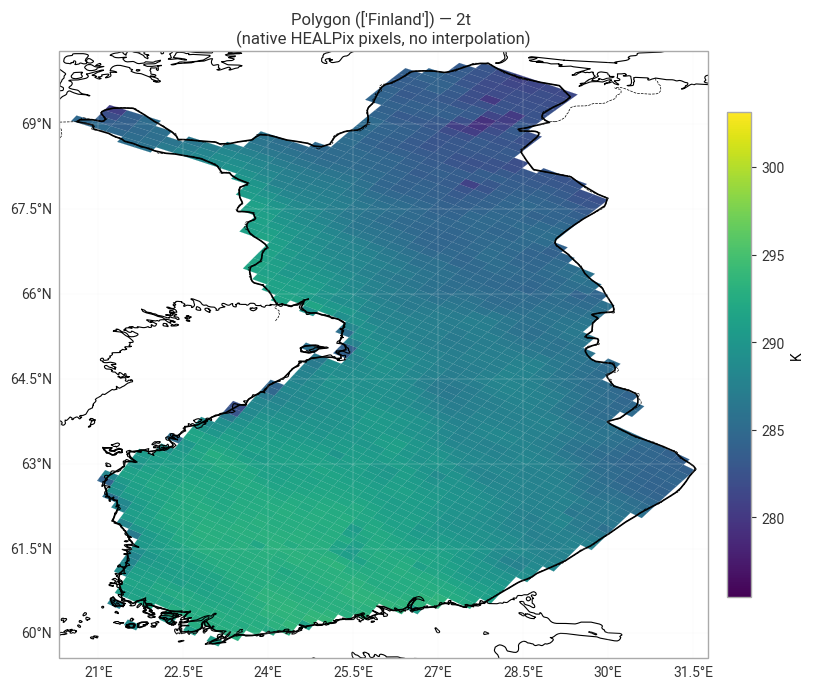

In [ ]:
# create map axes that we can use as basis for the plot
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

# Create a collection of the polygons
coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values) # Assign temperature values to each polygon
ax.add_collection(coll) # Add the collection to the map axis that we created before.

# Overlay country outline from earthkit-geo shapes
for shape in shapes:
    s_lons = [pt[1] for pt in shape]
    s_lats = [pt[0] for pt in shape]
    ax.plot(s_lons, s_lats, color="black", linewidth=1.2, transform=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")

#refine grids
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title(f"Polygon ({countries}) — 2t \n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()